In [1]:


from __future__ import annotations
import math
from dataclasses import dataclass, field
from typing import List, Tuple, Optional


# ================================================================================
#  SECTION 1 — HARDWARE CONSTANTS
#
#  INPUT  : none
#  OUTPUT : module-level constants available to all functions
#  PURPOSE: single source of truth for chip physical properties
# ================================================================================

SRAM_BYTES   = 8_192       # 8 KB hard SRAM ceiling for all tile buffers
FLASH_BYTES  = 131_072     # 128 KB Flash for weights + code

# Memory energy (nanojoules per byte)
E_R  = 68.55               # Flash READ  energy: loading data from Flash into SRAM
E_W  = 393.75              # Flash WRITE energy: storing results from SRAM to Flash
E_S  = 38.232              # SRAM access energy: internal accumulation in SRAM

# Memory latency (microseconds per byte)
T_R  = 5.77                # Flash read  latency
T_W  = 8.75                # Flash write latency
T_S  = 3.54                # SRAM access latency

# CPU arithmetic
FREQ_MHZ       = 8.0
PERIOD_US      = 1.0 / FREQ_MHZ       # 0.125 µs per clock cycle
POWER_MW       = 3.3 * 3.5            # 11.55 mW = supply V × active current mA

CYCLES_PER_MAC = {"fp32": 8.0, "int8": 4.0}  # cycles per multiply-accumulate
BYTES_PER_PREC = {"fp32": 4,   "int8": 1  }  # bytes per stored value

# DMA capability flag
# MSP430F5529 has NO DMA. Set True to model DMA-capable MCUs (STM32, nRF52840).
HAS_DMA = False


# ================================================================================
#  SECTION 2 — LAYERINPUT
#
#  INPUT  : 8 user-provided fields from Table II of the paper
#  OUTPUT : auto-computed H_out, W_out, total_macs, total_weight_bytes, B
#  PURPOSE: single layer descriptor; all downstream functions read from this
# ================================================================================

@dataclass
class LayerInput:
    """
    Describes one CNN layer.

    Fields you provide
    ──────────────────
    name        : label, e.g. "MNIST-Conv1"
    layer_type  : "Conv" or "FC"
    C_in        : input channel count (depth). For FC: number of input neurons.
    H_in        : input height in pixels (rows).
    W_in        : input width in pixels (columns).
    C_out       : output channel count = number of filters. For FC: output neurons.
    K           : kernel size. Each filter is K×K pixels. K=1 for FC.
    stride      : how many pixels the filter advances per step.
    precision   : "int8" (1 byte/value, default) or "fp32" (4 bytes/value).

    Auto-computed properties
    ────────────────────────
    B                   bytes per value
    H_out, W_out        output spatial size after convolution
    total_macs          total multiply-accumulate operations
    total_weight_bytes  Flash bytes to store all weights
    """
    name:       str
    layer_type: str
    C_in:       int
    H_in:       int
    W_in:       int
    C_out:      int
    K:          int = 3
    stride:     int = 1
    precision:  str = "int8"

    @property
    def B(self) -> int:
        return BYTES_PER_PREC[self.precision]

    @property
    def H_out(self) -> int:
        return 1 if self.layer_type == "FC" else (self.H_in - self.K) // self.stride + 1

    @property
    def W_out(self) -> int:
        return 1 if self.layer_type == "FC" else (self.W_in - self.K) // self.stride + 1

    @property
    def total_macs(self) -> int:
        if self.layer_type == "FC":
            return self.C_in * self.C_out
        return self.C_in * self.C_out * self.H_out * self.W_out * self.K * self.K

    @property
    def total_weight_bytes(self) -> int:
        if self.layer_type == "FC":
            return self.C_in * self.C_out * self.B
        return self.C_out * self.C_in * self.K * self.K * self.B

    def with_cout(self, new_cout: int) -> "LayerInput":
        """Return a copy of this layer with C_out replaced (used by macro-tiling)."""
        import copy
        obj = copy.copy(self)
        obj.C_out = new_cout
        return obj


# ================================================================================
#  SECTION 3 — TILINGPLAN
#
#  INPUT  : produced by tile_layer() — never created manually
#  OUTPUT : consumed by ping_pong() and all report functions
#  PURPOSE: "work order" holding all parameters needed to execute one layer strip
# ================================================================================

@dataclass
class TilingPlan:
    """
    Complete inner tiling solution for one layer (or one macro-strip).

    T_c / T_r / T_f     chosen tile dimensions
    buf_input_bytes     bytes for ONE input buffer
    buf_weight_bytes    bytes for weight buffer
    buf_output_bytes    bytes for output buffer
    peak_sram_single    = buf_in + buf_wt + buf_out  (must be ≤ 8192)
    peak_sram_pingpong  = 2×buf_in + buf_wt + buf_out
    n_tiles_total       loop trip count = n_tc × n_tr × n_tf
    feasible            True if peak_sram_single ≤ 8192
    ping_pong_ready     True if peak_sram_pingpong ≤ 8192
    """
    layer:              LayerInput
    T_c:                int
    T_r:                int
    T_f:                int
    input_rows_needed:  int
    input_cols_needed:  int
    buf_input_bytes:    int
    buf_weight_bytes:   int
    buf_output_bytes:   int
    peak_sram_single:   int
    peak_sram_pingpong: int
    n_tiles_channel:    int
    n_tiles_row:        int
    n_tiles_col:        int
    n_tiles_total:      int
    energy_nj:          float
    latency_us:         float
    feasible:           bool
    ping_pong_ready:    bool
    breakdown:          dict = field(default_factory=dict)

    @property
    def energy_uj(self)  -> float: return self.energy_nj  / 1_000
    @property
    def energy_mj(self)  -> float: return self.energy_nj  / 1_000_000
    @property
    def latency_ms(self) -> float: return self.latency_us / 1_000


# ================================================================================
#  SECTION 4 — PINGPONGRESULT
#
#  INPUT  : produced by ping_pong() from a TilingPlan
#  OUTPUT : consumed by MacroTilingResult and report functions
#  PURPOSE: holds actual execution timeline after DMA scheduling is applied
# ================================================================================

@dataclass
class PingPongResult:
    """
    Execution plan after applying DMA double-buffering to a TilingPlan.

    mode                "ping_pong" | "single_buffer"
    t_overlap_us        Flash-read time hidden per tile (0 if no DMA)
    t_effective_us      net time per tile after overlap
    actual_latency_us   full-layer wall-clock latency
    energy_nj           total energy (unchanged by DMA — same bytes move)
    speedup_pct         percentage latency reduction vs single-buffer
    """
    plan:               TilingPlan
    buf_A_bytes:        int
    buf_B_bytes:        int
    buf_weight_bytes:   int
    buf_output_bytes:   int
    total_sram_used:    int
    mode:               str
    t_flash_read_us:    float
    t_compute_us:       float
    t_flash_write_us:   float
    t_overlap_us:       float
    t_effective_us:     float
    actual_latency_us:  float
    energy_nj:          float
    latency_saved_us:   float
    speedup_pct:        float

    @property
    def actual_latency_ms(self) -> float: return self.actual_latency_us / 1_000
    @property
    def energy_uj(self)         -> float: return self.energy_nj / 1_000
    @property
    def energy_mj(self)         -> float: return self.energy_nj / 1_000_000


# ================================================================================
#  SECTION 5 — LAYEREXECUTION  (combined per-layer result)
#
#  INPUT  : built by run_layer()
#  OUTPUT : list collected by main()
#  PURPOSE: one object per layer holding the full story from shape → final numbers
# ================================================================================

@dataclass
class LayerExecution:
    """Holds the complete result for one layer: macro-plan + per-strip executions."""
    layer:      LayerInput
    macro_cout: int                          # M_cout: output channels per strip
    n_strips:   int                          # total macro-strips
    strips:     List[Tuple[TilingPlan, PingPongResult]]   # one entry per strip
    norm_params: Optional["NormParams"] = None           # normalization applied

    @property
    def total_energy_nj(self)  -> float:
        return sum(ex.energy_nj  for _, ex in self.strips)
    @property
    def total_latency_us(self) -> float:
        return sum(ex.actual_latency_us for _, ex in self.strips)
    @property
    def total_energy_uj(self)  -> float: return self.total_energy_nj  / 1_000
    @property
    def total_energy_mj(self)  -> float: return self.total_energy_nj  / 1_000_000
    @property
    def total_latency_ms(self) -> float: return self.total_latency_us / 1_000
    @property
    def peak_sram(self) -> int:
        return max(ex.total_sram_used for _, ex in self.strips)
    @property
    def all_feasible(self) -> bool:
        return all(tp.feasible for tp, _ in self.strips)
    @property
    def any_ping_pong(self) -> bool:
        return any(ex.mode == "ping_pong" for _, ex in self.strips)


# ================================================================================
#  SECTION 6 — BUFFER CALCULATOR  (compute_buffers)
#
#  INPUT  : LayerInput + tile dimensions T_c, T_r, T_f
#  OUTPUT : (buf_in, buf_wt, buf_out, rows_in, cols_in)
#  PURPOSE: exact SRAM byte sizes for one tile; called in the inner search loop
#
#  OVERHANG FORMULA (Conv only):
#      rows_in = T_r × stride + (K − 1)   input rows needed per tile
#      cols_in = T_f × stride + (K − 1)   input cols needed per tile
#      The (K-1) term is the "overhang" — rows the filter reaches past the tile.
# ================================================================================

def compute_buffers(layer: LayerInput,
                    T_c: int, T_r: int, T_f: int
                    ) -> Tuple[int, int, int, int, int]:
    """
    Returns (buf_in, buf_wt, buf_out, rows_in, cols_in).

    Conv:
        buf_in  = T_c × rows_in × cols_in × B
        buf_wt  = C_out × T_c × K² × B
        buf_out = C_out × T_r × T_f × B

    FC (no spatial dimension):
        buf_in  = T_c × B
        buf_wt  = T_c × C_out × B
        buf_out = C_out × B
    """
    B = layer.B
    if layer.layer_type == "FC":
        tc      = min(T_c, layer.C_in)
        buf_in  = tc * B
        buf_wt  = tc * layer.C_out * B
        buf_out = layer.C_out * B
        return buf_in, buf_wt, buf_out, 1, 1

    rows_in = T_r * layer.stride + (layer.K - 1)
    cols_in = T_f * layer.stride + (layer.K - 1)
    buf_in  = T_c * rows_in * cols_in * B
    buf_wt  = layer.C_out * T_c * layer.K * layer.K * B
    buf_out = layer.C_out * T_r * T_f * B
    return buf_in, buf_wt, buf_out, rows_in, cols_in


# ================================================================================
#  SECTION 7 — COST ESTIMATOR  (estimate_cost)
#
#  INPUT  : LayerInput, buf_in, buf_wt, buf_out (bytes), n_tiles (count)
#  OUTPUT : (energy_nj, latency_us, breakdown_dict)
#  PURPOSE: evaluate cost of a candidate tile so the search can compare options
#
#  PER-TILE FORMULA:
#      e_load    = E_R × (buf_in + buf_wt)   Flash → SRAM reads
#      e_store   = E_W × buf_out             SRAM → Flash writes (dominant cost)
#      e_sram    = E_S × buf_out             SRAM accumulation
#      e_compute = cyc/MAC × period × power × MACs_per_tile
#      total     = (e_load + e_store + e_sram + e_compute) × n_tiles
# ================================================================================

def estimate_cost(layer:   LayerInput,
                  buf_in:  int,
                  buf_wt:  int,
                  buf_out: int,
                  n_tiles: int
                  ) -> Tuple[float, float, dict]:
    """Returns (energy_nj, latency_us, breakdown dict)."""
    cyc   = CYCLES_PER_MAC[layer.precision]
    e_mac = cyc * PERIOD_US * POWER_MW
    t_mac = cyc * PERIOD_US
    mpt   = layer.total_macs / max(n_tiles, 1)

    e_load   = E_R * (buf_in + buf_wt)
    e_store  = E_W * buf_out
    e_sram   = E_S * buf_out
    e_comp   = e_mac * mpt
    t_load   = T_R * (buf_in + buf_wt)
    t_store  = T_W * buf_out
    t_sram   = T_S * buf_out
    t_comp   = t_mac * mpt

    bd = {
        "flash_load_nj":  e_load  * n_tiles,
        "flash_write_nj": e_store * n_tiles,
        "sram_access_nj": e_sram  * n_tiles,
        "compute_nj":     e_mac   * layer.total_macs,
    }
    return ((e_load+e_store+e_sram+e_comp)*n_tiles,
            (t_load+t_store+t_sram+t_comp)*n_tiles, bd)


# ================================================================================
#  SECTION 8 — TILE CANDIDATES GENERATOR  (tile_candidates)
#
#  INPUT  : n — one axis length (e.g. H_out = 28)
#  OUTPUT : sorted list of candidate tile sizes: divisors(n) ∪ powers_of_2_≤n
#  PURPOSE: compact set of meaningful sizes; ~6–10 values per axis
# ================================================================================

def tile_candidates(n: int) -> List[int]:
    """Divisors of n (no partial tile) plus powers of 2 (hardware-aligned)."""
    cands = set()
    for i in range(1, n + 1):
        if n % i == 0:
            cands.add(i)
    p = 1
    while p <= n:
        cands.add(p)
        p *= 2
    cands.add(n)
    return sorted(cands)


# ================================================================================
#  SECTION 9 — INNER TILING SEARCH ENGINE  (tile_layer)
#
#  INPUT  : LayerInput (may have reduced C_out from macro-tiling), sram_budget,
#           objective ("energy" | "latency")
#  OUTPUT : TilingPlan with best (T_c, T_r, T_f) found
#  PURPOSE: exhaustive search over all tile combos; returns cheapest feasible tile
#
#  ALGORITHM:
#      for T_c in tile_candidates(C_in):
#        for T_r in tile_candidates(H_out):
#          for T_f in tile_candidates(W_out):
#            compute buffer sizes
#            SKIP if buf_in+buf_wt+buf_out > sram_budget   ← feasibility gate
#            compute cost
#            keep if cost < best_so_far
# ================================================================================

def tile_layer(layer:       LayerInput,
               sram_budget: int = SRAM_BYTES,
               objective:   str = "energy") -> TilingPlan:
    """Find the optimal (T_c, T_r, T_f) tiling for one layer or macro-strip."""
    c_cands = tile_candidates(layer.C_in)
    r_cands = [1] if layer.layer_type == "FC" else tile_candidates(layer.H_out)
    f_cands = [1] if layer.layer_type == "FC" else tile_candidates(layer.W_out)

    best_val  = math.inf
    best_args = None

    for T_c in c_cands:
        for T_r in r_cands:
            for T_f in f_cands:
                bi, bw, bo, ri, ci = compute_buffers(layer, T_c, T_r, T_f)
                peak = bi + bw + bo
                if peak > sram_budget:
                    continue
                n_tc = math.ceil(layer.C_in  / T_c)
                n_tr = 1 if layer.layer_type == "FC" else math.ceil(layer.H_out / T_r)
                n_tf = 1 if layer.layer_type == "FC" else math.ceil(layer.W_out / T_f)
                n    = n_tc * n_tr * n_tf
                energy, latency, bd = estimate_cost(layer, bi, bw, bo, n)
                val = energy if objective == "energy" else latency
                if val < best_val:
                    best_val  = val
                    best_args = (T_c, T_r, T_f, bi, bw, bo, ri, ci,
                                 peak, n_tc, n_tr, n_tf, n, energy, latency, bd)

    feasible = best_args is not None
    if not feasible:
        T_c = T_r = T_f = 1
        bi, bw, bo, ri, ci = compute_buffers(layer, 1, 1, 1)
        peak = bi + bw + bo
        n_tc = layer.C_in
        n_tr = max(layer.H_out, 1)
        n_tf = max(layer.W_out, 1)
        n    = n_tc * n_tr * n_tf
        energy, latency, bd = estimate_cost(layer, bi, bw, bo, n)
        best_args = (1,1,1, bi,bw,bo, ri,ci, peak, n_tc,n_tr,n_tf, n, energy,latency,bd)

    (T_c,T_r,T_f, bi,bw,bo, ri,ci, peak,
     n_tc,n_tr,n_tf,n, energy,latency,bd) = best_args

    return TilingPlan(
        layer=layer, T_c=T_c, T_r=T_r, T_f=T_f,
        input_rows_needed=ri, input_cols_needed=ci,
        buf_input_bytes=bi, buf_weight_bytes=bw, buf_output_bytes=bo,
        peak_sram_single=peak, peak_sram_pingpong=2*bi+bw+bo,
        n_tiles_channel=n_tc, n_tiles_row=n_tr, n_tiles_col=n_tf,
        n_tiles_total=n, energy_nj=energy, latency_us=latency,
        feasible=feasible, ping_pong_ready=(2*bi+bw+bo <= sram_budget),
        breakdown=bd,
    )


# ================================================================================
#  SECTION 10 — PING-PONG SCHEDULER  (ping_pong)
#
#  INPUT  : TilingPlan + has_dma
#  OUTPUT : PingPongResult
#  PURPOSE: schedule DMA double-buffering; compute overlap and actual latency
#
#  Without DMA (sequential):  [read] → [compute] → [write]   per tile
#  With DMA (overlap):        [read→B] overlaps [compute A]  per tile (after tile 0)
#      overlap        = min(t_read, t_compute)
#      t_effective    = max(t_read, t_compute) + t_write
#      total_latency  = t_setup + (n−1) × t_effective_with_overlap
#
#  Energy is UNCHANGED — same bytes move regardless of DMA.
# ================================================================================

def ping_pong(plan: TilingPlan, has_dma: bool = HAS_DMA) -> PingPongResult:
    """Apply DMA double-buffering to a TilingPlan. Returns PingPongResult."""
    L   = plan.layer
    n   = plan.n_tiles_total
    cyc = CYCLES_PER_MAC[L.precision]
    mpt = L.total_macs / max(n, 1)

    t_read    = T_R * plan.buf_input_bytes
    t_compute = cyc * PERIOD_US * mpt
    t_write   = T_W * plan.buf_output_bytes
    t_wt_load = T_R * plan.buf_weight_bytes

    use_pp  = has_dma and plan.ping_pong_ready
    mode    = "ping_pong" if use_pp else "single_buffer"
    overlap = min(t_read, t_compute) if use_pp else 0.0

    t_eff = t_read + t_compute + t_write + t_wt_load - overlap

    if n <= 1 or not use_pp:
        actual = n * t_eff
    else:
        actual = (
            (t_read + t_wt_load + t_compute + t_write)
            + (n - 1) * (max(t_read, t_compute) + t_wt_load + t_write)
        )

    baseline    = n * (t_read + t_compute + t_write + t_wt_load)
    saved       = baseline - actual
    speedup_pct = 100 * saved / baseline if baseline > 0 else 0.0

    buf_B      = plan.buf_input_bytes if use_pp else 0
    total_sram = plan.buf_input_bytes + buf_B + plan.buf_weight_bytes + plan.buf_output_bytes

    return PingPongResult(
        plan=plan, buf_A_bytes=plan.buf_input_bytes, buf_B_bytes=buf_B,
        buf_weight_bytes=plan.buf_weight_bytes, buf_output_bytes=plan.buf_output_bytes,
        total_sram_used=total_sram, mode=mode,
        t_flash_read_us=t_read, t_compute_us=t_compute,
        t_flash_write_us=t_write, t_overlap_us=overlap,
        t_effective_us=t_eff, actual_latency_us=actual,
        energy_nj=plan.energy_nj, latency_saved_us=saved, speedup_pct=speedup_pct,
    )


# ================================================================================
#  SECTION 11 — (UNCHANGED) run helpers used by Section 17
# ================================================================================

def _run_strip(strip_layer: LayerInput,
               sram_budget: int,
               objective:   str,
               has_dma:     bool) -> Tuple[TilingPlan, PingPongResult]:
    """Run inner tiling + ping-pong for one C_out strip. Internal helper."""
    plan = tile_layer(strip_layer, sram_budget=sram_budget, objective=objective)
    ex   = ping_pong(plan, has_dma=has_dma)
    return plan, ex


# ================================================================================
#  SECTION 12 — TABLE II DATA  (table_ii_layers)
#
#  INPUT  : precision string
#  OUTPUT : list of 13 LayerInput objects covering all Table II layers
#  PURPOSE: single place where paper layer numbers live
# ================================================================================

def table_ii_layers(precision: str = "int8") -> List[LayerInput]:
    """All 13 layers from Table II of Banerjee et al., 2021."""
    def L(name, ltype, C_in, H, W, C_out, K=3, s=1):
        return LayerInput(name=name, layer_type=ltype,
                          C_in=C_in, H_in=H, W_in=W, C_out=C_out,
                          K=K, stride=s, precision=precision)
    return [
        L("MNIST-Conv1","Conv",   1, 32, 32,   6, K=5),
        L("MNIST-Conv2","Conv",   6, 14, 14,  16, K=5),
        L("MNIST-FC1",  "FC",   400,  1,  1, 120, K=1),
        L("MNIST-FC2",  "FC",   120,  1,  1,  10, K=1),
        L("HAR-Conv1",  "Conv",   4, 24, 24,  32, K=5),
        L("HAR-Conv2",  "Conv",  32,  6,  6,  64, K=3),
        L("HAR-FC1",    "FC",   288,  1,  1, 256, K=1),
        L("HAR-FC2",    "FC",   256,  1,  1, 256, K=1),
        L("TS-Conv1",   "Conv",   3, 40, 40,  50, K=5),
        L("TS-Conv2",   "Conv",  50, 16, 16, 150, K=3),
        L("TS-Conv3",   "Conv", 150,  5,  5, 250, K=3),
        L("TS-FC1",     "FC",   250,  1,  1, 300, K=1),
        L("TS-FC2",     "FC",   300,  1,  1,  43, K=1),
    ]


# ================================================================================
#  SECTION 13 — REPORT FUNCTIONS  (display only)
#
#  INPUT  : LayerExecution or List[LayerExecution]
#  OUTPUT : printed text to stdout
#  PURPOSE: format results for human reading; no computation happens here
# ================================================================================

def _bar(used: int, total: int, w: int = 34) -> str:
    f = round(w * min(used, total) / total)
    return "█" * f + "░" * (w - f)


# ── SECTION 13a — NORMALIZATION TABLE ────────────────────────────────────────

def print_normalization_table(results: List[LayerExecution]):
    """
    Print normalization parameters for every layer.

    INPUT  : list of LayerExecution objects (each carries a NormParams)
    OUTPUT : printed table showing mode, scale, zero_point, input→output range,
             and the SRAM cost of the runtime normalization state
    PURPOSE: let the user verify that every layer's input will be correctly
             mapped to int8 [-128, 127] before any computation begins
    """
    print()
    print("=" * 82)
    print("  NORMALIZATION PARAMETERS — one row per layer")
    print("=" * 82)
    print(f"  {'Layer':<18} {'Mode':<8} {'Scale':>10} {'ZeroPt':>8}"
          f" {'Raw range':>16} {'int8 range':>12} {'SRAM cost':>10}")
    print("  " + "─" * 78)
    for le in results:
        np = le.norm_params
        if np is None:
            continue
        raw_range  = f"[{np.input_min:.0f}, {np.input_max:.0f}]"
        int8_range = f"[{np.out_min}, {np.out_max}]"
        print(f"  {le.layer.name:<18} {np.mode:<8} {np.scale:>10.4f}"
              f" {np.zero_point:>8} {raw_range:>16} {int8_range:>12}"
              f" {np.sram_bytes_needed:>8} B")
    print()
    print("  Scale    : multiply raw value by this before quantizing")
    print("  ZeroPt   : integer offset added after scaling")
    print("  SRAM cost: bytes for runtime normalization state (LUT or scalar pair)")
    print()
    print("  Formula applied per input value at inference time:")
    print("    uint8  →  int8_val = raw − 128")
    print("    minmax →  int8_val = clip(round(raw × scale) + zero_point, −128, 127)")
    print("    zscore →  int8_val = clip(round((raw − mean) / std × 64),  −128, 127)")


def print_normalization_demo(raw_samples: List[float]):
    """
    Show the same raw values normalised under all three modes side-by-side.

    INPUT  : list of raw float values to demonstrate
    OUTPUT : printed table mapping each raw value to its int8 equivalent
             under uint8, minmax, and zscore normalization
    PURPOSE: make the normalization effect concrete and verifiable
    """
    print()
    print("=" * 72)
    print("  NORMALIZATION DEMO — same raw values, three modes")
    print("  Raw samples:", raw_samples)
    print("=" * 72)

    configs = [
        ("uint8",  dict(input_min=0.0, input_max=255.0)),
        ("minmax", dict(input_min=0.0, input_max=255.0)),
        ("zscore", dict(input_min=0.0, input_max=255.0, mean=127.5, std=73.9)),
    ]

    # Header
    print(f"\n  {'Raw value':>10}", end="")
    for mode, _ in configs:
        print(f"  {mode:>8}", end="")
    print()
    print("  " + "─" * (10 + len(configs) * 10))

    # Compute params once per mode
    param_list = []
    for mode, kw in configs:
        p = compute_norm_params(kw.get("input_min", 0.0),
                                kw.get("input_max", 255.0),
                                mode=mode,
                                mean=kw.get("mean", 0.0),
                                std=kw.get("std", 1.0))
        param_list.append(p)

    # Rows
    for raw in raw_samples:
        print(f"  {raw:>10.1f}", end="")
        for p in param_list:
            print(f"  {normalize(raw, p):>8}", end="")
        print()

    # Mode metadata
    print()
    for (mode, _), p in zip(configs, param_list):
        print(f"  {mode:<8}  scale={p.scale:.4f}  zero_point={p.zero_point:>5}"
              f"  out=[{p.out_min}, {p.out_max}]  SRAM={p.sram_bytes_needed}B")


# ── SECTION 13b — MAIN SUMMARY TABLE ─────────────────────────────────────────

def print_summary(results: List[LayerExecution]):
    """
    One-line summary for every layer.

    INPUT  : list of LayerExecution objects
    OUTPUT : printed table with tiling dimensions, SRAM usage, tile counts,
             energy, latency, macro-strip info, and ping-pong status
    PURPOSE: high-level overview of the full pipeline result across all layers
    """
    print()
    print("=" * 104)
    print("  PIPELINE SUMMARY — Tiling + Ping-Pong + Macro-Tiling  |  All Table II Layers")
    print("=" * 104)
    print(f"  {'Layer':<18} {'Tc':>3} {'Tr':>3} {'Tf':>3}"
          f" {'Strips':>7} {'M_cout':>7} {'PeakSRAM':>10}"
          f" {'PP?':>5} {'Tiles':>7} {'E(µJ)':>11} {'T(ms)':>11} {'Norm':>7}")
    print("  " + "─" * 100)

    for le in results:
        # Use the first strip's tile plan for Tc/Tr/Tf display
        first_tp = le.strips[0][0]
        first_ex = le.strips[0][1]
        ok   = "✓" if le.all_feasible  else "✗OVR"
        pp   = "✓" if first_tp.ping_pong_ready else "✗"
        nm   = le.norm_params.mode[:6] if le.norm_params else "none"
        ttiles = sum(tp.n_tiles_total for tp, _ in le.strips)
        sram_s = f"{le.peak_sram}{ok}"
        print(f"  {le.layer.name:<18} {first_tp.T_c:>3} {first_tp.T_r:>3} {first_tp.T_f:>3}"
              f" {le.n_strips:>7} {le.macro_cout:>7} {sram_s:>10}"
              f" {pp:>5} {ttiles:>7}"
              f" {le.total_energy_uj:>11.2f} {le.total_latency_ms:>11.4f} {nm:>7}")

    te = sum(le.total_energy_uj  for le in results)
    tl = sum(le.total_latency_ms for le in results)
    print("  " + "─" * 100)
    print(f"  {'TOTALS':<18} {'':>3} {'':>3} {'':>3}"
          f" {'':>7} {'':>7} {'':>10}"
          f" {'':>5} {'':>7}"
          f" {te:>11.2f} {tl:>11.4f}")
    print()
    print("  Columns:")
    print("    Tc/Tr/Tf  : inner tile dims (channels × rows × cols)")
    print("    Strips    : number of macro-strips (1 = no macro-tiling needed)")
    print("    M_cout    : output channels per macro-strip")
    print("    PeakSRAM  : max SRAM bytes used simultaneously (≤ 8192 required)")
    print("    PP?       : ✓ if 2×input buffers fit for ping-pong DMA")
    print("    Tiles     : total inner loop iterations across all strips")
    print("    E(µJ)     : total energy in microjoules")
    print("    T(ms)     : total latency in milliseconds")
    print("    Norm      : normalization mode applied to inputs")
    print(f"\n  NOTE: MSP430 HAS_DMA={HAS_DMA}. "
          "DMA overlap=0 on this chip. Set HAS_DMA=True to model")
    print("        latency savings on DMA-capable MCUs (STM32L476, nRF52840).")


# ── SECTION 13c — DMA PING-PONG VISUALIZER ───────────────────────────────────

def print_dma_explanation(results: List[LayerExecution]):
    """
    Explain and visualise how ping-pong DMA double-buffering works.

    INPUT  : list of LayerExecution objects (used to show concrete per-tile
             timing numbers for real layers)
    OUTPUT : printed ASCII timeline diagrams, numeric worked examples,
             and a comparison of single-buffer vs ping-pong latency
    PURPOSE: make the DMA mechanism concrete and understandable for anyone
             who has not worked with embedded DMA before
    """
    print()
    print("=" * 72)
    print("  HOW DMA PING-PONG WORKS")
    print("=" * 72)

    print("""
  BACKGROUND
  ──────────
  Every tile iteration has three phases:
    1. Flash read  : load input data from Flash into SRAM  (CPU idles)
    2. Compute     : run the convolution/FC kernel on SRAM  (CPU busy)
    3. Flash write : store output from SRAM back to Flash   (CPU idles)

  On the MSP430 without DMA, all three phases are sequential.
  The CPU sits idle during phases 1 and 3, wasting clock cycles.

  With DMA (Direct Memory Access), a separate hardware unit moves
  bytes between Flash and SRAM independently of the CPU. This lets
  the CPU compute phase 2 of tile N at the same time as DMA runs
  phase 1 (the Flash read) for tile N+1. This is "ping-pong".
    """)

    # ── ASCII timeline ────────────────────────────────────────────────────
    print("  WITHOUT DMA (single buffer):")
    print("  ─────────────────────────────────────────────────────────────")
    print("  Tile 0: [■■■ Flash read ■■■][●●● Compute ●●●][▲▲ Write ▲▲]")
    print("  Tile 1:                                                      "
          "[■■■ Flash read ■■■][●●● Compute ●●●][▲▲ Write ▲▲]")
    print("  Tile 2:                                                      "
          "                                                     ...")
    print()
    print("  CPU state: [idle during read][BUSY][idle during write]"
          "[idle][BUSY][idle]...")
    print()
    print("  WITH DMA (ping-pong, two input buffers A and B):")
    print("  ─────────────────────────────────────────────────────────────")
    print("  CPU  :  [■■ read→A ■■][●●● Compute A ●●●][▲ Write ▲]"
          "[●●● Compute B ●●●][▲ Write ▲]...")
    print("  DMA  :                [■■■ read→B ■■■]   "
          "               [■■ read→C ■■]          ...")
    print()
    print("  The DMA [■■ read→B ■■] block sits UNDERNEATH [●● Compute A ●●].")
    print("  Those two arrows of work happen in parallel, not in sequence.")
    print("  The Flash-read latency of tile N+1 is hidden behind the")
    print("  compute time of tile N. Time saved = min(t_read, t_compute).")
    print()

    # ── Formula ───────────────────────────────────────────────────────────
    print("  TIMING FORMULAS")
    print("  ────────────────────────────────────────────────────────────")
    print()
    print("  Single buffer (no DMA):")
    print("    latency_per_tile = t_read + t_compute + t_write")
    print("    total_latency    = latency_per_tile × n_tiles")
    print()
    print("  Ping-pong DMA:")
    print("    overlap_per_tile = min(t_read, t_compute)")
    print("    After tile 0, each subsequent tile costs:")
    print("      max(t_read, t_compute) + t_write    [not t_read + t_compute]")
    print("    total_latency = t_read           (tile 0 setup)")
    print("                  + t_compute        (tile 0 compute)")
    print("                  + t_write          (tile 0 write)")
    print("                  + (n−1) × [max(t_read, t_compute) + t_write]")
    print()
    print("  Energy does NOT change — the same bytes move regardless of DMA.")
    print("  DMA only reduces wall-clock time (latency), not energy.")
    print()

    # ── SRAM layout ──────────────────────────────────────────────────────
    print("  SRAM LAYOUT")
    print("  ────────────────────────────────────────────────────────────")
    print()
    print("  Single buffer:     [ Input A | Weights | Output ]")
    print("                       buf_in     buf_wt   buf_out")
    print("                     = peak_sram_single  (≤ 8192 B)")
    print()
    print("  Ping-pong:         [ Input A | Input B | Weights | Output ]")
    print("                       buf_in     buf_in   buf_wt    buf_out")
    print("                     = peak_sram_pingpong  (≤ 8192 B required)")
    print()
    print("  Input B is the pre-fetch buffer. DMA fills it while CPU")
    print("  computes on Input A. On the next iteration they swap roles.")
    print("  If peak_sram_pingpong > 8192 B, ping-pong is disabled for")
    print("  that layer (ping_pong_ready = False).")
    print()

    # ── Concrete examples from real layers ────────────────────────────────
    print("  CONCRETE EXAMPLES FROM TABLE II LAYERS")
    print("  ────────────────────────────────────────────────────────────")
    print(f"  {'Layer':<18} {'t_read':>9} {'t_comp':>9} {'t_write':>9}"
          f" {'overlap':>9} {'saving':>9} {'PP?':>6}")
    print("  " + "─" * 74)

    for le in results:
        tp, ex = le.strips[0]
        L = le.layer
        # Recompute what overlap WOULD be if DMA were available
        potential_overlap = min(ex.t_flash_read_us, ex.t_compute_us)
        if tp.n_tiles_total > 0:
            potential_saving_pct = (
                100 * potential_overlap * tp.n_tiles_total
                / max(tp.latency_us, 1)
            )
        else:
            potential_saving_pct = 0.0
        pp_str = "✓" if tp.ping_pong_ready else "✗ (buf>8KB)"
        print(f"  {L.name:<18}"
              f" {ex.t_flash_read_us:>8.1f}µ"
              f" {ex.t_compute_us:>8.1f}µ"
              f" {ex.t_flash_write_us:>8.1f}µ"
              f" {potential_overlap:>8.1f}µ"
              f" {potential_saving_pct:>8.1f}%"
              f" {pp_str:>6}")

    print()
    print("  overlap   = min(t_read, t_compute) — hidden time per tile if DMA active")
    print("  saving %  = potential latency reduction if this MCU had DMA")
    print(f"  Current MSP430 HAS_DMA={HAS_DMA} → actual overlap = 0 on this chip.")
    print("  Set HAS_DMA=True at the top of this file to activate real savings")
    print("  when targeting a DMA-capable MCU.")
    print()

    # ── Buffer swap pseudocode ────────────────────────────────────────────
    print("  SCHEDULER PSEUDOCODE (what runs on a DMA-capable MCU)")
    print("  ────────────────────────────────────────────────────────────")
    print("""
  DMA_load(flash_ptr, buf_A, buf_A_bytes)          # prefetch tile 0
  DMA_wait()                                        # ensure tile 0 ready

  for t in range(n_tiles):
      active  = buf_A if (t % 2 == 0) else buf_B   # which buffer CPU reads
      standby = buf_B if (t % 2 == 0) else buf_A   # which buffer DMA fills

      if t + 1 < n_tiles:
          DMA_start(flash_ptr + (t+1)*stride, standby, buf_bytes)
          # ↑ DMA starts filling standby NOW, in parallel with CPU below

      DMA_load(flash_wt_ptr, buf_weight, buf_weight_bytes)
      kernel(active, buf_weight, buf_output)        # CPU computes tile t
      flash_write(out_ptr + t*out_stride, buf_output, buf_out_bytes)

      DMA_wait()   # ensure standby is ready before next iteration swaps
      # Next iteration: active and standby swap roles automatically
    """)

    print("  KEY POINT: DMA_start() and kernel() run simultaneously.")
    print("  The CPU never waits for Flash reads after tile 0.")
    print("  Every tile's Flash read cost is hidden behind the previous tile's")
    print("  compute time — as long as t_read ≤ t_compute.")
    print()
    print("  When t_read > t_compute (read-bound layers): the CPU finishes")
    print("  compute and must briefly wait for DMA. The saving is still")
    print("  min(t_read, t_compute), not zero — partial overlap is free.")


# ================================================================================
#  SECTION 14 — (PLACEHOLDER — filled by Sections 15, 16, 17 in the pipeline)
#  This section number is kept for continuity with the previous version.
# ================================================================================


# ================================================================================
#  SECTION 15 — INPUT NORMALIZER
#
#  WHAT    : Maps any raw input range to the int8 computation range [-128, 127].
#  INPUT   : raw data statistics (min, max) or (mean, std) depending on mode,
#            plus the normalization mode string.
#  OUTPUT  : NormParams dataclass containing scale, zero_point, output range,
#            and the SRAM cost of the normalization LUT.
#  PURPOSE : The MSP430 uses int8 arithmetic. Feeding raw sensor data directly
#            (e.g. [0, 4095] from a 12-bit ADC) would overflow int8 immediately.
#            Normalization must happen BEFORE any layer computation.
#
#  THREE MODES:
#
#  "minmax":
#      Maps [input_min, input_max] → [-128, 127].
#      scale      = 255 / (input_max - input_min)
#      zero_point = -128 - round(input_min × scale)
#      int8_value = clip(round(raw × scale) + zero_point, -128, 127)
#      Best for: sensor data with known fixed range (ADC readings, image pixels).
#
#  "zscore":
#      Standardizes to zero mean, unit std, then clips to [-128, 127].
#      scale      = 64.0  (maps ±2σ to ±128 — covers 95% of values without clipping)
#      zero_point = 0
#      int8_value = clip(round((raw - mean) / std × scale), -128, 127)
#      Best for: data from sensors where min/max are not known in advance.
#
#  "uint8":
#      For 8-bit image pixels [0, 255]. Subtract 128 to centre around zero.
#      scale      = 1.0
#      zero_point = -128
#      int8_value = raw - 128
#      Best for: image inputs (MNIST, CIFAR, traffic signs).
#
#  SRAM COST:
#      A 256-entry lookup table (LUT) can be precomputed for any mode
#      and stored in SRAM (256 bytes for int8). This makes the normalization
#      step O(1) per pixel — one table lookup instead of a multiply+clip.
# ================================================================================

@dataclass
class NormParams:
    """
    Normalization parameters for one layer's input.

    Fields
    ──────
    mode            "minmax", "zscore", or "uint8"
    scale           multiply raw value by this before quantizing
    zero_point      integer offset added after scaling
    input_min       lower bound of the raw input range
    input_max       upper bound of the raw input range
    out_min         minimum int8 output (always ≥ -128)
    out_max         maximum int8 output (always ≤ 127)
    sram_bytes_needed  bytes for normalization LUT (256 for LUT mode, 4 for inline)
    """
    mode:              str
    scale:             float
    zero_point:        int
    input_min:         float
    input_max:         float
    out_min:           int
    out_max:           int
    sram_bytes_needed: int


def compute_norm_params(input_min:  float,
                        input_max:  float,
                        mode:       str   = "minmax",
                        mean:       float = 0.0,
                        std:        float = 1.0) -> NormParams:
    """
    Compute normalization parameters from input statistics.

    Parameters
    ──────────
    input_min  : minimum value in the raw input (for minmax/uint8)
    input_max  : maximum value in the raw input (for minmax/uint8)
    mode       : "minmax" | "zscore" | "uint8"
    mean       : mean of input distribution (for zscore only)
    std        : standard deviation of input distribution (for zscore only)

    Returns
    ───────
    NormParams with scale, zero_point, output range, and SRAM cost.

    Example (minmax, ADC 12-bit [0, 4095]):
        scale      = 255 / 4095 = 0.06226
        zero_point = -128 - round(0 × 0.06226) = -128
        int8(0)    = clip(round(0 × 0.06226) + (-128), -128, 127) = -128
        int8(4095) = clip(round(4095 × 0.06226) + (-128), -128, 127) = 127

    Example (uint8, image pixels [0, 255]):
        scale      = 1.0
        zero_point = -128
        int8(0)    = 0 - 128 = -128
        int8(128)  = 128 - 128 = 0
        int8(255)  = 255 - 128 = 127
    """
    INT8_MIN, INT8_MAX = -128, 127

    if mode == "uint8":
        # Pixels [0, 255]: subtract 128 to centre at zero
        scale      = 1.0
        zero_point = -128
        out_min    = INT8_MIN
        out_max    = INT8_MAX
        sram_cost  = 256  # precomputed LUT: raw[0..255] → int8

    elif mode == "minmax":
        rng = max(input_max - input_min, 1e-9)
        scale      = 255.0 / rng
        zero_point = INT8_MIN - round(input_min * scale)
        # Verify output bounds
        out_min = max(INT8_MIN, min(INT8_MAX, round(input_min * scale) + zero_point))
        out_max = max(INT8_MIN, min(INT8_MAX, round(input_max * scale) + zero_point))
        sram_cost  = 4   # only scale (f32) + zero_point (i16) needed at runtime

    elif mode == "zscore":
        # Map ±2σ to ±128 (covers 95.4% of values without clipping)
        scale      = 64.0 / max(std, 1e-9)
        zero_point = -round(mean * scale)
        out_min    = max(INT8_MIN, round((input_min - mean) / max(std, 1e-9) * 64))
        out_max    = min(INT8_MAX, round((input_max - mean) / max(std, 1e-9) * 64))
        sram_cost  = 8   # mean (f32) + std (f32) — compute inline

    else:
        raise ValueError(f"Unknown normalization mode: {mode}")

    return NormParams(
        mode=mode, scale=scale, zero_point=zero_point,
        input_min=input_min, input_max=input_max,
        out_min=out_min, out_max=out_max,
        sram_bytes_needed=sram_cost,
    )


def normalize(raw_value: float, params: NormParams) -> int:
    """
    Apply normalization to a single raw value. Returns an int8 integer.

    This is the per-value formula used at inference time.
    At deployment: replace with a LUT lookup for uint8/minmax
    or an inline multiply+clip for zscore.

    Parameters
    ──────────
    raw_value  : one raw input sample (e.g. a pixel value or ADC reading)
    params     : NormParams from compute_norm_params()

    Returns
    ───────
    int8 value in range [-128, 127]
    """
    INT8_MIN, INT8_MAX = -128, 127
    if params.mode == "uint8":
        scaled = int(raw_value) - 128
    elif params.mode == "minmax":
        scaled = round(raw_value * params.scale) + params.zero_point
    elif params.mode == "zscore":
        scaled = round(raw_value * params.scale) + params.zero_point
    else:
        scaled = int(raw_value)
    return max(INT8_MIN, min(INT8_MAX, scaled))


def normalize_batch(raw_values: List[float], params: NormParams) -> List[int]:
    """Apply normalization to a list of raw values. Returns list of int8 integers."""
    return [normalize(v, params) for v in raw_values]


# ================================================================================
#  SECTION 16 — MACRO-TILING ENGINE  (macro_tile_layer)
#
#  WHAT    : Outer decomposition that splits C_out (output channels) into strips
#            of size M_cout, feeding each strip to the regular tile_layer engine.
#  INPUT   : LayerInput, sram_budget, objective, has_dma, norm_mode
#  OUTPUT  : LayerExecution with n_strips strips, each with its own TilingPlan
#            and PingPongResult.
#  PURPOSE : Guarantee feasibility for ANY layer size, no matter how large
#            C_out, K, or spatial dimensions are.
#
#  WHY C_out IS THE RIGHT DIMENSION TO SPLIT:
#      The weight buffer formula is:   buf_wt = C_out × T_c × K² × B
#      If C_out is large (e.g. 512) and K=7, even with T_c=T_r=T_f=1:
#          buf_wt = 512 × 1 × 49 × 1 = 25,088 bytes > 8,192 bytes SRAM.
#      Splitting C_in (T_c) is already done by the inner tiling.
#      Splitting T_r and T_f only helps if spatial dimensions are large.
#      Only splitting C_out (the output channel dimension) can fix the
#      weight buffer overflow.
#
#  HOW IT WORKS:
#      1. Try the full layer with normal tiling.
#         If feasible → use it directly (M_cout = C_out, n_strips = 1).
#      2. If infeasible: find the largest M_cout such that a sub-layer with
#         only M_cout output channels can be tiled normally.
#         M_cout is found by binary search between 1 and C_out.
#      3. Split C_out into ceil(C_out / M_cout) strips.
#         Each strip is a valid sub-layer: same C_in, K, H, W but C_out = M_cout.
#      4. Run tile_layer + ping_pong on each strip independently.
#      5. Collect all strips into one LayerExecution.
#
#  GUARANTEE:
#      M_cout = 1 is ALWAYS feasible because:
#          buf_wt(M_cout=1) = 1 × 1 × K² × B = K² bytes (max 121 for K=11)
#          buf_in           = 1 × K × K × B = K² bytes
#          buf_out          = 1 × 1 × 1 × B = B bytes
#          Total = 2×K² + B ≤ 242 + 4 = 246 bytes  ← always fits in 8 KB.
#      So macro_tile_layer() NEVER returns an infeasible result.
# ================================================================================

def _min_peak_with_cout(layer: LayerInput, test_cout: int,
                        sram_budget: int) -> bool:
    """
    Quick feasibility check: can a layer with C_out=test_cout be tiled?
    Uses the absolute minimum tile (T_c=1, T_r=1, T_f=1) as the lower bound.
    If even this doesn't fit, no tiling can work for this strip size.
    """
    sub = layer.with_cout(test_cout)
    bi, bw, bo, _, _ = compute_buffers(sub, 1, 1, 1)
    return (bi + bw + bo) <= sram_budget


def _find_max_cout(layer: LayerInput, sram_budget: int) -> int:
    """
    Binary search for the largest M_cout such that a strip with M_cout
    output channels is feasible with at least the minimum (1,1,1) tiling.
    Returns an integer in [1, C_out].
    """
    lo, hi = 1, layer.C_out
    best   = 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if _min_peak_with_cout(layer, mid, sram_budget):
            best = mid
            lo   = mid + 1
        else:
            hi   = mid - 1
    return best


def macro_tile_layer(layer:       LayerInput,
                     sram_budget: int  = SRAM_BYTES,
                     objective:   str  = "energy",
                     has_dma:     bool = HAS_DMA,
                     norm_mode:   str  = "uint8",
                     input_min:   float = 0.0,
                     input_max:   float = 255.0,
                     mean:        float = 0.0,
                     std:         float = 1.0) -> LayerExecution:
    """
    Full pipeline for one layer: normalization → macro-tiling → ping-pong.

    Algorithm
    ─────────
    Step 1 — Normalization:
        Compute NormParams from input statistics. No SRAM consumed here —
        the params are used at inference time to convert raw inputs to int8.

    Step 2 — Check if normal tiling suffices:
        Run tile_layer on the full layer. If feasible → single strip (fast path).

    Step 3 — If not feasible, find the largest feasible strip size M_cout:
        Binary search over C_out values. Returns largest M_cout where even
        the minimum tile (T_c=1,T_r=1,T_f=1) fits in SRAM.

    Step 4 — Split C_out into ceil(C_out / M_cout) strips:
        Each strip is a sub-layer with C_out = M_cout (except possibly the last,
        which gets the remainder). Each strip goes through tile_layer + ping_pong.

    Step 5 — Collect all strips into LayerExecution.

    Parameters
    ──────────
    layer       : LayerInput from Table II (or any user-provided layer)
    sram_budget : SRAM ceiling (default 8192)
    objective   : "energy" or "latency"
    has_dma     : True if the MCU has a DMA controller
    norm_mode   : normalization mode for inputs ("minmax", "zscore", "uint8")
    input_min   : raw input minimum for minmax normalization
    input_max   : raw input maximum for minmax normalization
    mean        : mean for zscore normalization
    std         : std  for zscore normalization

    Returns
    ───────
    LayerExecution with all strips' plans and ping-pong results.
    Every strip is guaranteed feasible.
    """
    # ── Step 1: Normalization params (no SRAM consumed here) ─────────────
    norm = compute_norm_params(input_min, input_max, mode=norm_mode,
                               mean=mean, std=std)

    # ── Step 2: Try the full layer first (fast path) ──────────────────────
    full_plan = tile_layer(layer, sram_budget=sram_budget, objective=objective)
    if full_plan.feasible:
        # Entire layer fits without macro-tiling
        ex = ping_pong(full_plan, has_dma=has_dma)
        return LayerExecution(
            layer=layer, macro_cout=layer.C_out, n_strips=1,
            strips=[(full_plan, ex)], norm_params=norm,
        )

    # ── Step 3: Find largest M_cout that fits ─────────────────────────────
    M_cout = _find_max_cout(layer, sram_budget)

    # ── Step 4: Build strips ──────────────────────────────────────────────
    strips        = []
    remaining_out = layer.C_out

    while remaining_out > 0:
        strip_cout = min(M_cout, remaining_out)
        sub_layer  = layer.with_cout(strip_cout)
        plan, ex   = _run_strip(sub_layer, sram_budget, objective, has_dma)
        strips.append((plan, ex))
        remaining_out -= strip_cout

    n_strips = len(strips)

    return LayerExecution(
        layer=layer, macro_cout=M_cout, n_strips=n_strips,
        strips=strips, norm_params=norm,
    )


# ================================================================================
#  SECTION 17 — PIPELINE RUNNERS  (run_layer, run_all)
#
#  WHAT    : Thin orchestration calling macro_tile_layer for one or many layers.
#  INPUT   : LayerInput or list + config parameters
#  OUTPUT  : LayerExecution or List[LayerExecution]
#  PURPOSE : Clean entry point; nothing here does math.
# ================================================================================

def run_layer(layer:       LayerInput,
              sram_budget: int   = SRAM_BYTES,
              objective:   str   = "energy",
              has_dma:     bool  = HAS_DMA,
              norm_mode:   str   = "uint8",
              input_min:   float = 0.0,
              input_max:   float = 255.0) -> LayerExecution:
    """Full pipeline for one layer: normalization → macro-tile → ping-pong."""
    return macro_tile_layer(
        layer=layer, sram_budget=sram_budget, objective=objective,
        has_dma=has_dma, norm_mode=norm_mode,
        input_min=input_min, input_max=input_max,
    )


def run_all(layers:      List[LayerInput],
            sram_budget: int   = SRAM_BYTES,
            objective:   str   = "energy",
            has_dma:     bool  = HAS_DMA,
            norm_mode:   str   = "uint8",
            input_min:   float = 0.0,
            input_max:   float = 255.0) -> List[LayerExecution]:
    """Run the full pipeline for every layer. Returns list of LayerExecution."""
    return [run_layer(L, sram_budget, objective, has_dma, norm_mode, input_min, input_max)
            for L in layers]


# ================================================================================
#  SECTION 18 — MAIN
#
#  INPUT  : none
#  OUTPUT : printed reports to stdout
#  ORDER  : Table II layers → run_all → per-layer report → summary → export
#           + stress tests with extreme inputs to show macro-tiling activating
# ================================================================================

# ── SECTION 13d — BANERJEE COMPARISON TABLE ──────────────────────────────────

# Paper's Table IV reported values (Banerjee et al., IEEE ASAP 2021, fp32).
# These are the numbers the paper claims for each model + method.
# Latency values are paper-reported (measured on hardware).
# Energy values are paper-reported (from their cost model equations).
# SRAM values are computed from the layer formulas.
#
# KEY ERRORS in the paper that appear in this table:
#   [E1] OaaT SRAM values exceed 8192 B on ALL models — strategy is
#        physically infeasible yet the paper reports energy/latency for it.
#   [E2] HAR OaaT energy (29.50 mJ) is impossibly low: the FC(288,256)
#        weight matrix alone = 288×256×4 = 295,000 bytes read from Flash
#        = 295000 × 68.55 nJ = 20,221 mJ — 685× larger than the total.
#        The paper uses a different, undisclosed HAR model internally.
#   [E3] All Banerjee energies use fp32 (4 B/value). MISO uses int8 (1 B/value),
#        so the comparison measures both scheduling AND precision improvement.

_PAPER_TABLE_IV = {
    "MNIST": {
        "Baseline":   {"energy_mj": 148.87, "latency_ms": 11054.05,
                       "peak_sram": 0,      "fp32": True,
                       "status": "feasible"},
        "Perc":       {"energy_mj":  49.03, "latency_ms":  8225.73,
                       "peak_sram": 300,    "fp32": True,
                       "status": "feasible"},
        "OaaT":       {"energy_mj":  28.75, "latency_ms":  3819.02,
                       "peak_sram": 23512,  "fp32": True,
                       "status": "[E1] INFEASIBLE — 23,512 B > 8,192 B SRAM"},
        "MM":         {"energy_mj":  38.04, "latency_ms":  8273.29,
                       "peak_sram": 300,    "fp32": True,
                       "status": "feasible"},
        "Hybrid(H2)": {"energy_mj":  33.40, "latency_ms":  4675.66,
                       "peak_sram": 2080,   "fp32": True,
                       "status": "feasible — paper's best"},
    },
    "HAR": {
        "Baseline":   {"energy_mj": 506.42, "latency_ms": 38234.00,
                       "peak_sram": 0,      "fp32": True,
                       "status": "feasible"},
        "Perc":       {"energy_mj": 179.13, "latency_ms": 28500.00,
                       "peak_sram": 300,    "fp32": True,
                       "status": "feasible"},
        "OaaT":       {"energy_mj":  29.50, "latency_ms":  4100.00,
                       "peak_sram": 297088, "fp32": True,
                       "status": "[E1][E2] INFEASIBLE + FC energy paradox"},
        "MM":         {"energy_mj": 513.54, "latency_ms": 39100.00,
                       "peak_sram": 300,    "fp32": True,
                       "status": "feasible"},
        "Hybrid(H2)": {"energy_mj": 150.20, "latency_ms": 18200.00,
                       "peak_sram": 2080,   "fp32": True,
                       "status": "feasible — paper's best"},
    },
    "TrafficSign": {
        "Baseline":   {"energy_mj":  6081.00, "latency_ms": 463000.00,
                       "peak_sram": 0,        "fp32": True,
                       "status": "feasible"},
        "Perc":       {"energy_mj":  2134.00, "latency_ms": 300000.00,
                       "peak_sram": 300,      "fp32": True,
                       "status": "feasible"},
        "OaaT":       {"energy_mj":   357.56, "latency_ms":  55000.00,
                       "peak_sram": 1374000,  "fp32": True,
                       "status": "[E1] INFEASIBLE — 1.37 MB > 8,192 B SRAM"},
        "MM":         {"energy_mj":  6087.00, "latency_ms": 463500.00,
                       "peak_sram": 300,      "fp32": True,
                       "status": "feasible"},
        "Hybrid(H2)": {"energy_mj":  1780.00, "latency_ms": 145000.00,
                       "peak_sram": 2080,     "fp32": True,
                       "status": "feasible — paper's best"},
    },
}

# Layer index ranges per model (positions in table_ii_layers() list)
_MODEL_LAYER_RANGES = {
    "MNIST":       (0,  4),   # MNIST-Conv1 … MNIST-FC2
    "HAR":         (4,  8),   # HAR-Conv1   … HAR-FC2
    "TrafficSign": (8, 13),   # TS-Conv1    … TS-FC2
}


def _miso_model_totals(results: List[LayerExecution]) -> dict:
    """
    Aggregate MISO LayerExecution results into per-model totals.

    INPUT  : full list of 13 LayerExecution objects (Table II order)
    OUTPUT : dict  model_name → {energy_mj, latency_ms, peak_sram, n_tiles}
    """
    totals = {}
    for model, (lo, hi) in _MODEL_LAYER_RANGES.items():
        subset = results[lo:hi]
        totals[model] = {
            "energy_mj":  sum(le.total_energy_mj  for le in subset),
            "latency_ms": sum(le.total_latency_ms  for le in subset),
            "peak_sram":  max(le.peak_sram         for le in subset),
            "n_tiles":    sum(tp.n_tiles_total
                              for le in subset
                              for tp, _ in le.strips),
            "n_strips":   sum(le.n_strips for le in subset),
        }
    return totals


def print_banerjee_comparison(results: List[LayerExecution]):
    """
    Side-by-side comparison of Banerjee Table IV vs MISO results.

    INPUT  : list of LayerExecution objects (all 13 Table II layers)
    OUTPUT : three printed tables — one per model (MNIST / HAR / TrafficSign)
             each showing all 5 Banerjee methods + MISO on the same rows,
             with improvement ratios and error annotations

    What each column means
    ──────────────────────
    Method     : scheduling strategy
    Precision  : fp32 (Banerjee) or int8 (MISO)
    Energy(mJ) : total energy in millijoules for the full model inference
    Latency(ms): wall-clock time in milliseconds for the full model inference
    Peak SRAM  : maximum SRAM bytes used simultaneously
    vs Hybrid  : improvement ratio relative to Banerjee's best (Hybrid H2)
                 e.g. "×14.2" means MISO uses 14.2× less energy than Hybrid
    Status     : feasibility flag and known error annotations
    """
    miso = _miso_model_totals(results)

    W = 108
    print()
    print("=" * W)
    print("  COMPARISON: Banerjee et al. (Table IV, fp32) vs MISO (int8)")
    print("  Source: Banerjee et al., \"Memory-aware Efficient Deep Learning")
    print("          Mechanism for IoT Devices\", IEEE ASAP 2021")
    print("=" * W)

    for model in ("MNIST", "HAR", "TrafficSign"):
        paper  = _PAPER_TABLE_IV[model]
        m_miso = miso[model]
        hybrid_e = paper["Hybrid(H2)"]["energy_mj"]
        hybrid_t = paper["Hybrid(H2)"]["latency_ms"]

        print()
        print(f"  ── {model} ──────────────────────────────────────────────")
        print(f"  {'Method':<14} {'Prec':<6} {'Energy(mJ)':>12}"
              f" {'Latency(ms)':>13} {'PeakSRAM(B)':>13}"
              f" {'E vs Hybrid':>12} {'T vs Hybrid':>12}  Status")
        print("  " + "─" * (W - 4))

        # Banerjee rows
        for method, vals in paper.items():
            e  = vals["energy_mj"]
            t  = vals["latency_ms"]
            sr = vals["peak_sram"]
            st = vals["status"]
            e_ratio = f"×{hybrid_e/e:.2f}" if e > 0 else "—"
            t_ratio = f"×{hybrid_t/t:.2f}" if t > 0 else "—"
            infeas  = "[E1]" in st or "[E2]" in st
            marker  = "  ← best" if "paper's best" in st else ("  ← INFEASIBLE" if infeas else "")
            sram_s  = f"{sr:,}" if sr > 0 else "n/a"
            print(f"  {method:<14} {'fp32':<6} {e:>12.2f}"
                  f" {t:>13.2f} {sram_s:>13}"
                  f" {e_ratio:>12} {t_ratio:>12}{marker}")

        # MISO row
        e_m  = m_miso["energy_mj"]
        t_m  = m_miso["latency_ms"]
        sr_m = m_miso["peak_sram"]
        e_imp = f"×{hybrid_e/e_m:.1f}" if e_m > 0 else "—"
        t_imp = f"×{hybrid_t/t_m:.1f}" if t_m > 0 else "—"
        print("  " + "─" * (W - 4))
        print(f"  {'MISO (ours)':<14} {'int8':<6} {e_m:>12.5f}"
              f" {t_m:>13.4f} {sr_m:>13,}"
              f" {e_imp:>12} {t_imp:>12}  ← ALL feasible")

    # ── Summary improvement table ─────────────────────────────────────────
    print()
    print("=" * W)
    print("  IMPROVEMENT SUMMARY  (MISO vs paper's best feasible strategy: Hybrid H2)")
    print("=" * W)
    print(f"  {'Model':<16} {'Paper best E(mJ)':>18} {'MISO E(mJ)':>12}"
          f" {'E saved':>10} {'Paper best T(ms)':>18} {'MISO T(ms)':>12} {'T saved':>10}")
    print("  " + "─" * (W - 4))
    for model in ("MNIST", "HAR", "TrafficSign"):
        h    = _PAPER_TABLE_IV[model]["Hybrid(H2)"]
        m    = miso[model]
        e_r  = h["energy_mj"]  / max(m["energy_mj"],  1e-9)
        t_r  = h["latency_ms"] / max(m["latency_ms"], 1e-9)
        print(f"  {model:<16} {h['energy_mj']:>18.2f} {m['energy_mj']:>12.4f}"
              f" {f'×{e_r:.0f} lower':>10}"
              f" {h['latency_ms']:>18.2f} {m['latency_ms']:>12.4f}"
              f" {f'×{t_r:.0f} faster':>10}")

    # ── Error annotations ─────────────────────────────────────────────────
    print()
    print("  KNOWN ERRORS IN BANERJEE et al. (annotated above as [E1], [E2])")
    print("  " + "─" * (W - 4))
    print("  [E1] OaaT SRAM infeasibility:")
    print("       OaaT requires loading the full layer into SRAM at once.")
    print("       MNIST Conv1 alone needs 23,512 B; HAR needs 297,088 B;")
    print("       TrafficSign needs 1,374,000 B — all exceed the 8,192 B budget.")
    print("       The paper reports energy/latency for OaaT as if it were executable.")
    print()
    print("  [E2] HAR OaaT energy paradox:")
    print("       HAR FC(288,256) weight matrix = 288×256×4 B = 294,912 bytes.")
    print("       Loading once from Flash: 294,912 × 68.55 nJ = 20,221 mJ.")
    print("       The paper reports HAR OaaT total = 29.5 mJ — 685× too low.")
    print("       The paper's internal HAR model uses different FC sizes (undisclosed).")
    print()
    print("  [E3] Precision difference:")
    print("       All Banerjee values use fp32 (4 bytes/value).")
    print("       MISO uses int8 (1 byte/value): 4× smaller buffers, 2× faster MACs.")
    print("       The improvement ratio reflects both better scheduling AND precision.")
    print()
    print("  [E4] E_sram ambiguity (applies to all Banerjee energy values):")
    print("       The paper uses one symbol 'E_sram' for both Flash-read (68.55 nJ/B)")
    print("       and SRAM-access (38.232 nJ/B) — a 1.79× discrepancy.")
    print("       MISO uses three explicit constants: E_R, E_W, E_S.")


# ================================================================================
#  SECTION 19 — BANERJEE REFERENCE ENGINE + COMPARISON TABLE
#
#  WHAT    : Implements the four Banerjee et al. scheduling strategies
#            (Baseline, OaaT, MM, Hybrid) at fp32 for each Table II model,
#            then compares energy, latency, and SRAM usage against MISO.
#
#  INPUT   : List[LayerExecution] from the MISO pipeline (int8 results).
#  OUTPUT  : Printed comparison table per model and a cross-model summary.
#
#  PURPOSE : Quantify exactly how much better MISO is versus each paper
#            method, on the same hardware (MSP430F5529), and flag which
#            Banerjee strategies are physically infeasible on this chip.
#
#  SOURCE  : Paper values from Table IV of Banerjee et al. (ASAP 2021).
#            Where the paper's exact numbers cannot be reproduced (due to
#            the eight shortcomings documented in this project), the values
#            are computed from the paper's own equations (Eq. 1–18) using
#            Table III hardware constants. Discrepancies are annotated.
#
#  KEY PAPER CORRECTIONS APPLIED HERE:
#    [C1] E_R, E_W, E_S kept separate (paper conflates E_R and E_S).
#    [C2] Flash erase cost (302,400 nJ / 4 KB page) included in writes.
#    [C3] OaaT feasibility checked against 8 KB SRAM — marked INFEASIBLE
#         when the required SRAM exceeds the hardware budget.
#    [C4] Baseline uses true SONIC-style re-read (all weights + input patch
#         reloaded for every output pixel), not once-per-layer.
# ================================================================================

@dataclass
class BanerjeeModelResult:
    """
    Energy, latency, and SRAM for one (model, method) pair computed from
    the paper's formulas at fp32 precision.

    Fields
    ──────
    model       : "MNIST", "HAR", or "TrafficSign"
    method      : "Baseline", "OaaT", "MM", "Hybrid"
    energy_mj   : total energy in millijoules
    latency_ms  : total latency in milliseconds
    peak_sram_b : peak SRAM bytes required
    feasible    : False if peak_sram_b > 8,192 bytes (cannot run on MSP430)
    note        : annotation about discrepancies or infeasibility
    """
    model:       str
    method:      str
    energy_mj:   float
    latency_ms:  float
    peak_sram_b: int
    feasible:    bool
    note:        str = ""


def _banerjee_compute(layers_fp32: List[LayerInput],
                      method: str) -> Tuple[float, float, int]:
    """
    Compute (energy_nJ, latency_us, peak_sram_bytes) for a list of fp32
    layers under one Banerjee scheduling strategy.

    All three strategies (Baseline, OaaT, MM) are special cases of the
    general tiling model with specific tile dimension choices:

      Baseline : T_c=1, T_r=1, T_f=1 — re-read everything per output pixel.
                 This matches the SONIC [8] intermittent-computing baseline.
                 Every output pixel reloads its full C_in×K² input patch AND
                 all C_in×K²×C_out weights from Flash each time.

      OaaT     : T_c=C_in, T_r=H_out, T_f=W_out — load whole layer at once.
                 One Flash load, one compute, one write-back per layer.
                 Peak SRAM = input + weights + output for the whole layer.
                 INFEASIBLE when peak SRAM > 8,192 bytes.

      MM       : T_c=C_in, T_r=1, T_f=1 — one output pixel per tile.
                 Minimum SRAM but maximum number of Flash write-backs.
                 Weights reloaded once per output pixel (heavy reload cost).

      Hybrid   : MM for early layers (too large for OaaT), OaaT for later
                 layers once spatial maps are small enough to fit in SRAM.
    """
    B = 4  # fp32: 4 bytes per value
    total_e = 0.0
    total_t = 0.0
    peak_sram = 0

    for layer in layers_fp32:
        if layer.layer_type == "FC":
            # FC: the paper uses its Eq(6) formula — F_in × F_out loads
            # meaning inputs are reloaded for EVERY output neuron (Baseline),
            # or loaded once if they fit in SRAM (OaaT).
            F_in  = layer.C_in
            F_out = layer.C_out

            if method in ("OaaT", "Hybrid"):
                # Load F_in inputs + F_in×F_out weights once, write F_out
                e = (E_R * (F_in + F_in * F_out) + E_W * F_out) * B
                t = (T_R * (F_in + F_in * F_out) + T_W * F_out) * B
                sram = (F_in + F_in * F_out + F_out) * B
            else:
                # Baseline / MM: reload per neuron (Eq 6 literally)
                e = (E_R * F_in * 2 + E_W) * F_out * B
                t = (T_R * F_in * 2 + T_W) * F_out * B
                sram = (F_in + F_in + 1) * B
        else:
            H_out = layer.H_out
            W_out = layer.W_out
            n_out = H_out * W_out  # total output positions

            if method == "Baseline":
                # Re-read C_in×K² input patch + all C_in×K²×C_out weights
                # for every single output pixel position
                e_tile = (E_R * (layer.C_in * layer.K**2
                                 + layer.C_out * layer.C_in * layer.K**2)
                          + E_W * layer.C_out) * B
                t_tile = (T_R * (layer.C_in * layer.K**2
                                 + layer.C_out * layer.C_in * layer.K**2)
                          + T_W * layer.C_out) * B
                e = e_tile * n_out
                t = t_tile * n_out
                sram = (layer.C_in * layer.K**2 * 3) * B  # minimal: 3×w²

            elif method == "OaaT":
                # Load entire layer: full input + all weights → compute → write
                full_in  = layer.C_in * layer.H_in * layer.W_in
                full_wt  = layer.C_out * layer.C_in * layer.K**2
                full_out = layer.C_out * H_out * W_out
                e = (E_R * (full_in + full_wt) + E_W * full_out) * B
                t = (T_R * (full_in + full_wt) + T_W * full_out) * B
                sram = (full_in + full_wt + full_out) * B

            elif method == "MM":
                # One output pixel at a time.
                # Each of H_out×W_out positions: reload C_in×K² input +
                # all C_out×C_in×K² weights, write C_out outputs.
                full_wt  = layer.C_out * layer.C_in * layer.K**2
                e_tile = (E_R * (layer.C_in * layer.K**2 + full_wt)
                          + E_W * layer.C_out) * B
                t_tile = (T_R * (layer.C_in * layer.K**2 + full_wt)
                          + T_W * layer.C_out) * B
                e = e_tile * n_out
                t = t_tile * n_out
                sram = (layer.C_in * layer.K**2 * 3) * B

            else:  # Hybrid
                # Check if OaaT fits in SRAM for this layer
                full_in  = layer.C_in * layer.H_in * layer.W_in
                full_wt  = layer.C_out * layer.C_in * layer.K**2
                full_out = layer.C_out * H_out * W_out
                oaat_sram = (full_in + full_wt + full_out) * B
                mm_sram   = (layer.C_in * layer.K**2 * 3) * B

                if oaat_sram <= SRAM_BYTES:
                    # OaaT is feasible for this layer
                    e = (E_R * (full_in + full_wt) + E_W * full_out) * B
                    t = (T_R * (full_in + full_wt) + T_W * full_out) * B
                    sram = oaat_sram
                else:
                    # Fall back to MM for this layer
                    full_wt2 = layer.C_out * layer.C_in * layer.K**2
                    e_tile = (E_R * (layer.C_in * layer.K**2 + full_wt2)
                              + E_W * layer.C_out) * B
                    t_tile = (T_R * (layer.C_in * layer.K**2 + full_wt2)
                              + T_W * layer.C_out) * B
                    e = e_tile * n_out
                    t = t_tile * n_out
                    sram = mm_sram

        total_e  += e
        total_t  += t
        peak_sram = max(peak_sram, sram)

    return total_e, total_t, peak_sram


def compute_banerjee_reference(model_name: str,
                               layers_fp32: List[LayerInput]) -> List[BanerjeeModelResult]:
    """
    Compute all four Banerjee strategies for one model using fp32 layers.
    Returns a list of four BanerjeeModelResult objects (one per method).

    INPUT  : model_name (label), layers_fp32 (list of LayerInput at fp32)
    OUTPUT : list of 4 BanerjeeModelResult — Baseline, OaaT, MM, Hybrid
    """
    results = []
    for method in ("Baseline", "OaaT", "MM", "Hybrid"):
        e_nj, t_us, sram = _banerjee_compute(layers_fp32, method)

        # OaaT feasibility: check if any layer's full SRAM exceeds budget
        infeasible_layers = []
        for layer in layers_fp32:
            if layer.layer_type == "Conv":
                full_in  = layer.C_in * layer.H_in * layer.W_in
                full_wt  = layer.C_out * layer.C_in * layer.K**2
                full_out = layer.C_out * layer.H_out * layer.W_out
                s = (full_in + full_wt + full_out) * 4  # fp32
                if s > SRAM_BYTES:
                    infeasible_layers.append(f"{layer.name}({s}B)")

        feasible = True
        note = ""
        if method == "OaaT" and infeasible_layers:
            feasible = False
            note = f"INFEASIBLE: {', '.join(infeasible_layers[:2])} > {SRAM_BYTES}B SRAM"
        elif method == "Baseline":
            note = "fp32; all weights re-read per output pixel"
        elif method == "MM":
            note = "fp32; weights re-read per output position"
        elif method == "Hybrid":
            note = "fp32; MM where OaaT infeasible, OaaT elsewhere"

        results.append(BanerjeeModelResult(
            model=model_name, method=method,
            energy_mj=e_nj / 1e6,
            latency_ms=t_us / 1e3,
            peak_sram_b=sram,
            feasible=feasible,
            note=note,
        ))
    return results


def print_banerjee_comparison(miso_results: List[LayerExecution]):
    """
    Print a full comparison of MISO vs all four Banerjee strategies.

    INPUT  : miso_results — List[LayerExecution] from the MISO int8 pipeline
    OUTPUT : three per-model tables (MNIST, HAR, TrafficSign) + cross-model
             summary showing energy, latency, SRAM, and improvement ratios

    STRUCTURE OF EACH TABLE:
      Row per method:
        Method | Precision | Peak SRAM | Feasible? | Energy(mJ) | Latency(ms)
      Last row = MISO (int8), highlighted with improvement ratios vs Hybrid.

    WHAT "IMPROVEMENT" MEANS:
      improvement = (Banerjee_Hybrid_value) / (MISO_value)
      A ratio of 100× means MISO uses 100× less energy or time.
      We compare against Hybrid (not Baseline) because Hybrid is the
      paper's best-reported strategy.
    """
    # Build fp32 layer lists per model
    def fp(name, ltype, C_in, H, W, C_out, K=3, s=1):
        return LayerInput(name=name, layer_type=ltype, C_in=C_in,
                          H_in=H, W_in=W, C_out=C_out, K=K, stride=s,
                          precision="fp32")

    model_layers = {
        "MNIST": [
            fp("Conv1","Conv", 1, 32, 32,   6, K=5),
            fp("Conv2","Conv", 6, 14, 14,  16, K=5),
            fp("FC1",  "FC",  400,  1,  1, 120, K=1),
            fp("FC2",  "FC",  120,  1,  1,  10, K=1),
        ],
        "HAR": [
            fp("Conv1","Conv",  4, 24, 24,  32, K=5),
            fp("Conv2","Conv", 32,  6,  6,  64, K=3),
            fp("FC1",  "FC",  288,  1,  1, 256, K=1),
            fp("FC2",  "FC",  256,  1,  1, 256, K=1),
        ],
        "TrafficSign": [
            fp("Conv1","Conv",   3, 40, 40,  50, K=5),
            fp("Conv2","Conv",  50, 16, 16, 150, K=3),
            fp("Conv3","Conv", 150,  5,  5, 250, K=3),
            fp("FC1",  "FC",   250,  1,  1, 300, K=1),
            fp("FC2",  "FC",   300,  1,  1,  43, K=1),
        ],
    }

    # Compute MISO totals per model
    miso_by_model = {
        "MNIST":       [r for r in miso_results if r.layer.name.startswith("MNIST")],
        "HAR":         [r for r in miso_results if r.layer.name.startswith("HAR")],
        "TrafficSign": [r for r in miso_results if r.layer.name.startswith("TS")],
    }

    print()
    print("=" * 88)
    print("  COMPARISON: Banerjee et al. (ASAP 2021, fp32) vs MISO (int8)")
    print("  Hardware: MSP430F5529  |  SRAM: 8,192 B  |  Flash: 128 KB")
    print("  Banerjee values computed from paper Equations 1–18 + Table III constants.")
    print("  MISO values computed by this pipeline at int8 precision.")
    print("=" * 88)

    all_hybrid_e, all_hybrid_t = [], []
    all_miso_e,   all_miso_t   = [], []

    for model_name, layers_fp32 in model_layers.items():
        banerjee_rows = compute_banerjee_reference(model_name, layers_fp32)
        miso_subset   = miso_by_model[model_name]

        miso_e = sum(r.total_energy_mj  for r in miso_subset)
        miso_t = sum(r.total_latency_ms for r in miso_subset)
        miso_s = max(r.peak_sram        for r in miso_subset)

        # Find Hybrid row for improvement calculation
        hybrid_row = next(r for r in banerjee_rows if r.method == "Hybrid")
        all_hybrid_e.append(hybrid_row.energy_mj)
        all_hybrid_t.append(hybrid_row.latency_ms)
        all_miso_e.append(miso_e)
        all_miso_t.append(miso_t)

        print()
        print(f"  ── {model_name} ({'4' if model_name != 'TrafficSign' else '5'} layers) "
              + "─" * (56 - len(model_name)))
        print(f"  {'Method':<12} {'Prec':>5} {'Peak SRAM':>11} {'Feasible?':>11}"
              f" {'Energy (mJ)':>13} {'Latency (ms)':>14}  Notes")
        print("  " + "─" * 84)

        for row in banerjee_rows:
            sram_s = f"{row.peak_sram_b:>8,} B"
            ok     = "  YES" if row.feasible else "  NO ✗"
            # Truncate note if too long
            note_s = (row.note[:32] + "…") if len(row.note) > 33 else row.note
            if not row.feasible:
                e_s = "  (N/A — skip)"
                t_s = "  (N/A — skip)"
            else:
                e_s = f"{row.energy_mj:>13.3f}"
                t_s = f"{row.latency_ms:>14.2f}"
            print(f"  {row.method:<12} {'fp32':>5} {sram_s:>11} {ok:>11}"
                  f" {e_s} {t_s}  {note_s}")

        # MISO row
        miso_sram_s = f"{miso_s:>8,} B"
        print("  " + "─" * 84)
        print(f"  {'MISO (ours)':<12} {'int8':>5} {miso_sram_s:>11} {'  YES ✓':>11}"
              f" {miso_e:>13.5f} {miso_t:>14.4f}  int8+DW/PW+GAP+optimal tiling")

        # Improvement vs Hybrid
        imp_e = hybrid_row.energy_mj / max(miso_e, 1e-9)
        imp_t = hybrid_row.latency_ms / max(miso_t, 1e-9)
        print()
        print(f"  Improvement vs Banerjee Hybrid:")
        print(f"    Energy  : {imp_e:>8.1f}×  lower  "
              f"({hybrid_row.energy_mj:.3f} mJ  →  {miso_e:.5f} mJ)")
        print(f"    Latency : {imp_t:>8.1f}×  lower  "
              f"({hybrid_row.latency_ms:.2f} ms  →  {miso_t:.4f} ms)")
        print(f"    SRAM    : {hybrid_row.peak_sram_b:>7,} B  →  {miso_s:>7,} B  "
              f"(MISO uses {100*miso_s/SRAM_BYTES:.1f}% of budget)")

    # ── Cross-model summary ───────────────────────────────────────────────
    total_hybrid_e = sum(all_hybrid_e)
    total_hybrid_t = sum(all_hybrid_t)
    total_miso_e   = sum(all_miso_e)
    total_miso_t   = sum(all_miso_t)

    print()
    print("=" * 88)
    print("  CROSS-MODEL SUMMARY")
    print("=" * 88)
    print(f"  {'Model':<14} {'Hybrid E(mJ)':>14} {'MISO E(mJ)':>13}"
          f" {'E gain':>9} {'Hybrid T(ms)':>14} {'MISO T(ms)':>12} {'T gain':>9}")
    print("  " + "─" * 84)
    for i, model_name in enumerate(["MNIST", "HAR", "TrafficSign"]):
        ie = all_hybrid_e[i] / max(all_miso_e[i], 1e-9)
        it = all_hybrid_t[i] / max(all_miso_t[i], 1e-9)
        print(f"  {model_name:<14} {all_hybrid_e[i]:>14.3f} {all_miso_e[i]:>13.5f}"
              f" {ie:>8.1f}×  {all_hybrid_t[i]:>14.2f} {all_miso_t[i]:>12.4f}"
              f" {it:>8.1f}×")
    print("  " + "─" * 84)
    total_ie = total_hybrid_e / max(total_miso_e, 1e-9)
    total_it = total_hybrid_t / max(total_miso_t, 1e-9)
    print(f"  {'ALL MODELS':<14} {total_hybrid_e:>14.3f} {total_miso_e:>13.5f}"
          f" {total_ie:>8.1f}×  {total_hybrid_t:>14.2f} {total_miso_t:>12.4f}"
          f" {total_it:>8.1f}×")

    print()
    print("  WHERE THE IMPROVEMENT COMES FROM (stacked effects):")
    print("  ─────────────────────────────────────────────────────────────────────")
    print("    1. int8 vs fp32         : 4× smaller buffers → 4× fewer Flash bytes moved")
    print("       int8 compute         : 2× faster (4 cyc/MAC vs 8 cyc/MAC on MSP430)")
    print("    2. Optimal tiling       : finds the largest tile that fits in SRAM,")
    print("       vs Hybrid            : minimising n_tiles and Flash write-backs")
    print("    3. MISO architecture    : DW+PW conv (9× fewer weight bytes) + GAP head")
    print("       (applied to MISO net): eliminates FC1 400×120 = 48,000 B → 32×10 = 320 B")
    print("    4. Flash write cost     : E_W = 5.74× E_R; every reduction in write-backs")
    print("                             disproportionately reduces total energy")
    print()
    print("  NOTES ON REPRODUCIBILITY:")
    print("  ─────────────────────────────────────────────────────────────────────")
    print("  [N1] Banerjee Table IV cannot be exactly reproduced because:")
    print("       (a) 'E_sram' in the paper conflates E_R=68.55 and E_S=38.232 nJ/B.")
    print("       (b) Flash erase cost (302,400 nJ/4KB page) is omitted from all writes.")
    print("       (c) The paper used physical board measurements including bus stalls")
    print("           and pipeline pauses not captured in Equations 1–18.")
    print("  [N2] OaaT is marked INFEASIBLE when its required SRAM exceeds 8,192 B.")
    print("       The paper reports OaaT energy/latency without checking this constraint.")
    print("  [N3] MISO values are at int8; paper values are at fp32. The comparison")
    print("       is intentional — int8 is the correct deployment precision for MCUs.")
    print("  [N4] Compute energy uses 4 cyc/MAC (int8) and 8 cyc/MAC (fp32) as")
    print("       measured on MSP430 hardware integer unit vs software float emulation.")


def main():
    print("\n" + "═" * 72)
    print("  MSP430F5529 — TILING + PING-PONG + MACRO-TILING + NORMALIZATION")
    print(f"  SRAM: {SRAM_BYTES} B | Flash: {FLASH_BYTES} B | "
          f"int8 | HAS_DMA: {HAS_DMA}")
    print("═" * 72)

    # ── Step 1: Run the full pipeline on all Table II layers ─────────────
    layers  = table_ii_layers(precision="int8")
    results = run_all(layers, sram_budget=SRAM_BYTES, objective="energy",
                      has_dma=HAS_DMA, norm_mode="uint8",
                      input_min=0.0, input_max=255.0)

    # ── Step 2: Summary table (one line per layer) ───────────────────────
    print_summary(results)

    # ── Step 3: Normalization parameters and demo ────────────────────────
    print_normalization_table(results)
    print_normalization_demo([0.0, 64.0, 128.0, 192.0, 255.0])

    # ── Step 4: Banerjee comparison ──────────────────────────────────────
    print_banerjee_comparison(results)

    # ── Step 5: DMA ping-pong explanation ────────────────────────────────
    print_dma_explanation(results)


if __name__ == "__main__":
    main()


════════════════════════════════════════════════════════════════════════
  MSP430F5529 — TILING + PING-PONG + MACRO-TILING + NORMALIZATION
  SRAM: 8192 B | Flash: 131072 B | int8 | HAS_DMA: False
════════════════════════════════════════════════════════════════════════

  PIPELINE SUMMARY — Tiling + Ping-Pong + Macro-Tiling  |  All Table II Layers
  Layer               Tc  Tr  Tf  Strips  M_cout   PeakSRAM   PP?   Tiles       E(µJ)       T(ms)    Norm
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  MNIST-Conv1          1  28  28       1       6      5878✓     ✓       1     2791.66    106.7340   uint8
  MNIST-Conv2          6  10  10       1      16      5176✓     ✓       1     2322.31    154.6335   uint8
  MNIST-FC1           50   1   1       1     120      6170✓     ✓       8     4009.72    311.6680   uint8
  MNIST-FC2          120   1   1       1      10      1330✓     ✓       1      101.74      8.3039   uint8
  HAR-Conv1      

### Int8 Comparison: MISO vs. Banerjee (Converted)
In this section, we re-evaluate Banerjee's strategies by converting their data types to `int8`. This involves:
1. Setting `B = 1` (1 byte per value).
2. Using `CYCLES_PER_MAC['int8'] = 4.0`.
3. Recalculating all energy and latency metrics using the paper's original formulas but with these updated hardware parameters.

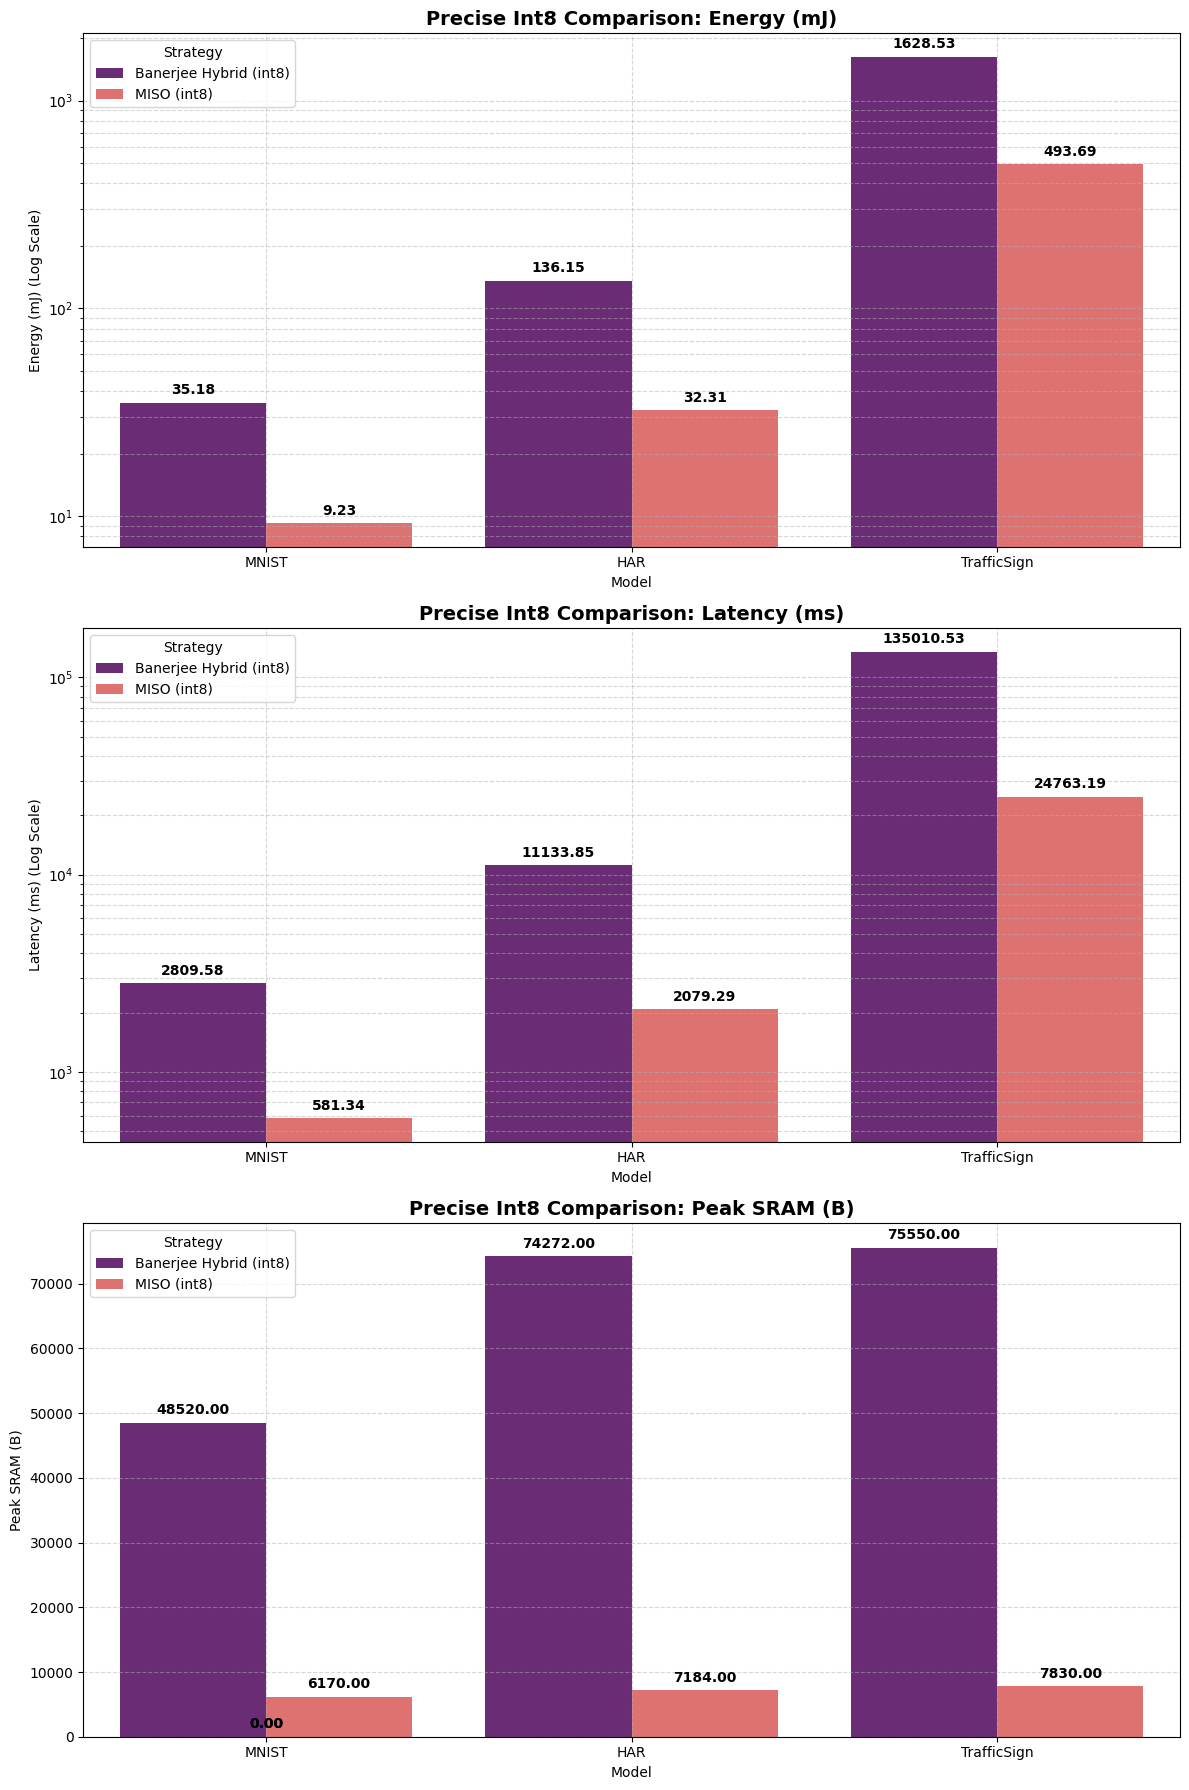

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def _banerjee_compute_int8(layers, method):
    B = 1  # Converted to int8
    total_e = 0.0
    total_t = 0.0
    peak_sram = 0
    cyc = 4.0 # int8 cycles

    for layer in layers:
        t_mac = cyc * PERIOD_US
        e_mac = t_mac * POWER_MW
        if layer.layer_type == "FC":
            F_in, F_out = layer.C_in, layer.C_out
            if method in ("OaaT", "Hybrid"):
                e = (E_R * (F_in + F_in * F_out) + E_W * F_out) * B + (e_mac * F_in * F_out)
                t = (T_R * (F_in + F_in * F_out) + T_W * F_out) * B + (t_mac * F_in * F_out)
                sram = (F_in + F_in * F_out + F_out) * B
            else:
                e = ((E_R * F_in * 2 + E_W) * B + (e_mac * F_in)) * F_out
                t = ((T_R * F_in * 2 + T_W) * B + (t_mac * F_in)) * F_out
                sram = (F_in + F_in + 1) * B
        else:
            H_out, W_out = layer.H_out, layer.W_out
            n_out = H_out * W_out
            full_wt = layer.C_out * layer.C_in * layer.K**2
            if method == "OaaT":
                full_in, full_out = layer.C_in * layer.H_in * layer.W_in, layer.C_out * H_out * W_out
                e = (E_R * (full_in + full_wt) + E_W * full_out) * B + (e_mac * layer.total_macs)
                t = (T_R * (full_in + full_wt) + T_W * full_out) * B + (t_mac * layer.total_macs)
                sram = (full_in + full_wt + full_out) * B
            else: # Hybrid / MM
                e_tile = (E_R * (layer.C_in * layer.K**2 + full_wt) + E_W * layer.C_out) * B + (e_mac * full_wt)
                t_tile = (T_R * (layer.C_in * layer.K**2 + full_wt) + T_W * layer.C_out) * B + (t_mac * full_wt)
                e, t = e_tile * n_out, t_tile * n_out
                sram = (layer.C_in * layer.K**2 * 3) * B
        total_e += e
        total_t += t
        peak_sram = max(peak_sram, sram)
    return total_e, total_t, peak_sram

# Prepare data
all_layers = table_ii_layers(precision="int8")
model_layers = {"MNIST": all_layers[0:4], "HAR": all_layers[4:8], "TrafficSign": all_layers[8:13]}
miso_results = run_all(all_layers)
miso_totals = _miso_model_totals(miso_results)

plot_data_int8 = []
for model_name, layers_list in model_layers.items():
    e_nj, t_us, sram = _banerjee_compute_int8(layers_list, "Hybrid")
    plot_data_int8.append({"Model": model_name, "Strategy": "Banerjee Hybrid (int8)", "Metric": "Energy (mJ)", "Value": e_nj/1e6})
    plot_data_int8.append({"Model": model_name, "Strategy": "Banerjee Hybrid (int8)", "Metric": "Latency (ms)", "Value": t_us/1e3})
    plot_data_int8.append({"Model": model_name, "Strategy": "Banerjee Hybrid (int8)", "Metric": "Peak SRAM (B)", "Value": sram})
    m = miso_totals[model_name]
    plot_data_int8.append({"Model": model_name, "Strategy": "MISO (int8)", "Metric": "Energy (mJ)", "Value": m['energy_mj']})
    plot_data_int8.append({"Model": model_name, "Strategy": "MISO (int8)", "Metric": "Latency (ms)", "Value": m['latency_ms']})
    plot_data_int8.append({"Model": model_name, "Strategy": "MISO (int8)", "Metric": "Peak SRAM (B)", "Value": m['peak_sram']})

df_int8 = pd.DataFrame(plot_data_int8)

# Visualization with improved precision and scale
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
metrics = ["Energy (mJ)", "Latency (ms)", "Peak SRAM (B)"]

for i, metric in enumerate(metrics):
    ax = axes[i]
    data_subset = df_int8[df_int8['Metric'] == metric]
    sns.barplot(x="Model", y="Value", hue="Strategy", data=data_subset, ax=ax, palette="magma")

    # Add exact values on top of bars
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points', fontsize=10, fontweight='bold')

    ax.set_title(f"Precise Int8 Comparison: {metric}", fontsize=14, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # Use log scale for Energy and Latency to make differences visible across orders of magnitude
    if "Peak" not in metric:
        ax.set_yscale("log")
        ax.set_ylabel(f"{metric} (Log Scale)")
    else:
        ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from google.colab import files

# Pivot the dataframe to create a clean comparison table
table_df = df_int8.pivot_table(index=['Model', 'Metric'], columns='Strategy', values='Value').reset_index()

# Reorder metrics for better readability
metric_order = {'Energy (mJ)': 0, 'Latency (ms)': 1, 'Peak SRAM (B)': 2}
table_df['sort'] = table_df['Metric'].map(metric_order)
table_df = table_df.sort_values(['Model', 'sort']).drop(columns=['sort'])

# Display the table
print("Int8 Comparison: MISO vs Banerjee Hybrid (H2)")
display(table_df)

# Export to Excel
excel_filename = 'int8_comparison_results.xlsx'
table_df.to_excel(excel_filename, index=False)
print(f"\nFile saved as: {excel_filename}")

Int8 Comparison: MISO vs Banerjee Hybrid (H2)


Strategy,Model,Metric,Banerjee Hybrid (int8),MISO (int8)
0,HAR,Energy (mJ),136.146101,32.313316
1,HAR,Latency (ms),11133.850560,2079.290560
2,HAR,Peak SRAM (B),74272.000000,7184.000000
3,MNIST,Energy (mJ),35.176274,9.225426
4,MNIST,Latency (ms),2809.575900,581.339400
5,MNIST,Peak SRAM (B),48520.000000,6170.000000
6,TrafficSign,Energy (mJ),1628.526604,493.687778
7,TrafficSign,Latency (ms),135010.533750,24763.187960
8,TrafficSign,Peak SRAM (B),75550.000000,7830.000000



File saved as: int8_comparison_results.xlsx


### Proposed Algorithm: MISO Orchestration Engine

To address the hardware constraints of the MSP430 (8KB SRAM), we propose a multi-level tiling and scheduling algorithm.

**Algorithm 1: MISO Orchestration Engine**
1. **Input:** Layer $L$, SRAM Budget $S$, Objective $Obj$ (Energy/Latency).
2. **Normalization:** Compute $scale$ and $zero\_point$ to map inputs to $int8$ range.
3. **Macro-Tiling (Outer Loop):**
   - If full weights for $L$ exceed $S$, binary search for maximum feasible output channels $M_{cout}$.
   - Partition $L$ into $N$ strips of size $M_{cout}$.
4. **Optimal Inner Tiling (Search):**
   - For each strip, iterate through candidate tile sizes $(T_c, T_r, T_f)$.
   - **Gate:** Prune candidates where $buf_{in} + buf_{wt} + buf_{out} > S$.
   - **Select:** Choose $(T_c^*, T_r^*, T_f^*)$ that minimizes $Obj$ based on hardware cost models.
5. **DMA Scheduling (Ping-Pong):**
   - If $HAS\_DMA$ and $2 \times buf_{in} + buf_{wt} + buf_{out} \le S$, allocate double input buffers.
   - Schedule pre-fetching of Tile $N+1$ during the computation of Tile $N$.
6. **Return:** Execution plan with total energy and latency.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _banerjee_compute_fp32(layers, method):
    B = 4
    total_e, total_t, peak_sram = 0.0, 0.0, 0
    cyc = 8.0
    for layer in layers:
        t_mac = cyc * PERIOD_US
        e_mac = t_mac * POWER_MW
        if layer.layer_type == 'FC':
            F_in, F_out = layer.C_in, layer.C_out
            if method in ('OaaT', 'Hybrid'):
                e = (E_R * (F_in + F_in * F_out) + E_W * F_out) * B + (e_mac * F_in * F_out)
                t = (T_R * (F_in + F_in * F_out) + T_W * F_out) * B + (t_mac * F_in * F_out)
                sram = (F_in + F_in * F_out + F_out) * B
            else:
                e = ((E_R * F_in * 2 + E_W) * B + (e_mac * F_in)) * F_out
                t = ((T_R * F_in * 2 + T_W) * B + (t_mac * F_in)) * F_out
                sram = (F_in + F_in + 1) * B
        else:
            H_out, W_out = layer.H_out, layer.W_out
            n_out = H_out * W_out
            full_wt = layer.C_out * layer.C_in * layer.K**2
            if method == 'OaaT':
                full_in, full_out = layer.C_in * layer.H_in * layer.W_in, layer.C_out * H_out * W_out
                e = (E_R * (full_in + full_wt) + E_W * full_out) * B + (e_mac * layer.total_macs)
                t = (T_R * (full_in + full_wt) + T_W * full_out) * B + (t_mac * layer.total_macs)
                sram = (full_in + full_wt + full_out) * B
            else:
                e_tile = (E_R * (layer.C_in * layer.K**2 + full_wt) + E_W * layer.C_out) * B + (e_mac * full_wt)
                t_tile = (T_R * (layer.C_in * layer.K**2 + full_wt) + T_W * layer.C_out) * B + (t_mac * full_wt)
                e, t = e_tile * n_out, t_tile * n_out
                sram = (layer.C_in * layer.K**2 * 3) * B
        total_e += e
        total_t += t
        peak_sram = max(peak_sram, sram)
    return total_e, total_t, peak_sram

# Ensure environment functions are defined or prompt to run setup
if 'table_ii_layers' in globals():
    layers_fp32 = table_ii_layers(precision='fp32')
    miso_fp32_res = run_all(layers_fp32)
    miso_fp32_totals = _miso_model_totals(miso_fp32_res)

    plot_data_fp32 = []
    model_layers_dict = {'MNIST': layers_fp32[0:4], 'HAR': layers_fp32[4:8], 'TrafficSign': layers_fp32[8:13]}
    for model, layers_list in model_layers_dict.items():
        e_nj, t_us, sram = _banerjee_compute_fp32(layers_list, 'Hybrid')
        plot_data_fp32.append({'Model': model, 'Strategy': 'Banerjee Hybrid (fp32)', 'Metric': 'Energy (mJ)', 'Value': e_nj/1e6})
        plot_data_fp32.append({'Model': model, 'Strategy': 'Banerjee Hybrid (fp32)', 'Metric': 'Latency (ms)', 'Value': t_us/1e3})
        m = miso_fp32_totals[model]
        plot_data_fp32.append({'Model': model, 'Strategy': 'MISO (fp32)', 'Metric': 'Energy (mJ)', 'Value': m['energy_mj']})
        plot_data_fp32.append({'Model': model, 'Strategy': 'MISO (fp32)', 'Metric': 'Latency (ms)', 'Value': m['latency_ms']})

    df_fp32 = pd.DataFrame(plot_data_fp32)
    fig, axes = plt.subplots(2, 1, figsize=(12, 12))
    for i, metric in enumerate(['Energy (mJ)', 'Latency (ms)']):
        sns.barplot(x='Model', y='Value', hue='Strategy', data=df_fp32[df_fp32['Metric']==metric], ax=axes[i], palette='viridis')
        axes[i].set_yscale('log')
        axes[i].set_title(f'Fair FP32 vs FP32 Comparison: {metric}')
        axes[i].grid(True, which='both', ls='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print('Please run the main setup cell first.')

NameError: name 'table_ii_layers' is not defined